**AI/ML Internship — Week 5**                                    
**Build & Compare 4 Classification Models — Titanic Survival Prediction**                                          
**Dataset:** Titanic — Machine Learning from Disaster                                        
**Student Name**: [Usman Asif]                                                   
**Date**: [24 May,26]

**PART A — DATA PREPARATION & BASELINE CLASSIFIER**

**Step 1 — Environment Setup & Dataset Loading**

In [119]:
# ================================
# STEP 1 — ENVIRONMENT SETUP
# ================================

import warnings
warnings.filterwarnings('ignore')

# Basic Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
import joblib

# Statistical Tools
from scipy.stats import shapiro, probplot

# Model Selection
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    StratifiedKFold,
    cross_val_score,
    learning_curve
)

# Preprocessing
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Classification Models
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.ensemble import RandomForestClassifier

# Evaluation Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    average_precision_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# ================================
# LOAD DATASET
# ================================

df = pd.read_csv('train.csv')

# Shape
print("Dataset Shape:")
print(df.shape)

# Information
print("\nDataset Info:")
print(df.info())

# Statistical Summary
print("\nDataset Description:")
print(df.describe())

# Target Variable
y = df['Survived']

# Class Balance
print("\nClass Distribution:")
print(y.value_counts())

print("\nClass Balance Ratio:")
print(y.value_counts(normalize=True))

Dataset Shape:
(891, 12)

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None

Dataset Description:
       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.3

## Class Imbalance Analysis

The Titanic dataset is moderately imbalanced.

- Class 0 (Did Not Survive): approximately 61%
- Class 1 (Survived): approximately 39%

This imbalance is important because classification models may become biased toward the majority class. Therefore, metrics such as Precision, Recall, F1-score, and ROC-AUC are more informative than Accuracy alone.

**Step 2 — Feature Engineering & Preprocessing**

In [120]:
# ================================
# STEP 2 — FEATURE ENGINEERING
# ================================

# Fill missing Age values with median
df['Age'].fillna(df['Age'].median(), inplace=True)

# Fill missing Embarked values with mode
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)

# Feature Engineering
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

df['IsAlone'] = (df['FamilySize'] == 1).astype(int)

# Log Transformation on Fare
df['Fare'] = np.log1p(df['Fare'])

# Encode Gender
df['Sex'] = df['Sex'].map({
    'male': 1,
    'female': 0
})

# Drop Unnecessary Columns
df.drop(
    ['Cabin', 'PassengerId', 'Name', 'Ticket'],
    axis=1,
    inplace=True
)

# One-Hot Encoding
df = pd.get_dummies(
    df,
    columns=['Embarked'],
    drop_first=True
)

# ================================
# CHECK RESULTS
# ================================

print("Final Dataset Shape:")
print(df.shape)

print("\nRemaining Missing Values:")
print(df.isnull().sum())

print("\nTotal Missing Values:")
print(df.isnull().sum().sum())

print("\nNo Missing Values Left:")
print(df.isnull().sum().sum() == 0)

print("\nFinal Columns:")
print(df.columns)

Final Dataset Shape:
(891, 11)

Remaining Missing Values:
Survived      0
Pclass        0
Sex           0
Age           0
SibSp         0
Parch         0
Fare          0
FamilySize    0
IsAlone       0
Embarked_Q    0
Embarked_S    0
dtype: int64

Total Missing Values:
0

No Missing Values Left:
True

Final Columns:
Index(['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare',
       'FamilySize', 'IsAlone', 'Embarked_Q', 'Embarked_S'],
      dtype='object')


**Step 3 — Train-Test Split & Scaling**

In [121]:
# ================================
# STEP 3 — TRAIN TEST SPLIT
# ================================

# Features and Target
X = df.drop('Survived', axis=1)
y = df['Survived']

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# ================================
# CLASS BALANCE CHECK
# ================================

print("Training Set Class Balance:")
print(y_train.value_counts(normalize=True))

print("\nTesting Set Class Balance:")
print(y_test.value_counts(normalize=True))

# ================================
# FEATURE SCALING
# ================================

scaler = StandardScaler()

# Fit ONLY on training data
X_train_s = scaler.fit_transform(X_train)

# Transform test data
X_test_s = scaler.transform(X_test)

# ================================
# VERIFY SCALING
# ================================

print("\nScaled Training Mean:")
print(np.round(X_train_s.mean(), 4))

print("\nScaled Training Standard Deviation:")
print(np.round(X_train_s.std(), 4))

Training Set Class Balance:
Survived
0    0.616573
1    0.383427
Name: proportion, dtype: float64

Testing Set Class Balance:
Survived
0    0.614525
1    0.385475
Name: proportion, dtype: float64

Scaled Training Mean:
0.0

Scaled Training Standard Deviation:
1.0


## Why is stratify=y Important?

The Titanic dataset is imbalanced because the number of passengers who did not survive is larger than the number who survived.

Using stratify=y ensures that both the training set and testing set maintain the same class distribution as the original dataset.

Without stratification:
- One split may contain too many survivors
- Another split may contain too few survivors
- Model evaluation becomes unreliable
- Accuracy may become misleading

Stratification improves fairness, stability, and reliability of classification model evaluation.

**Step 4 — Write the evaluate_classifier() Utility Function**

In [122]:
results = []

# ================================
# STEP 4 — EVALUATION FUNCTION
# ================================

def evaluate_model(
    y_true: np.ndarray,
    y_pred: np.ndarray,
    model_name: str,
    n_features: int
) -> dict:
    """
    Evaluate classification results using regression-style metrics.

    Parameters
    ----------
    y_true : np.ndarray
        Actual target values
    y_pred : np.ndarray
        Predicted target values
    model_name : str
        Name of the model
    n_features : int
        Number of features used in model

    Returns
    -------
    dict
        Dictionary containing all evaluation metrics
    """

    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)

    n = len(y_true)
    adj_r2 = 1 - ((1 - r2) * (n - 1) / (n - n_features - 1))

    mape = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-10))) * 100

    metrics = {
        "Model": model_name,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R2": r2,
        "Adjusted_R2": adj_r2,
        "MAPE": mape
    }

    print(f"\n===== {model_name} =====")
    for k, v in metrics.items():
        if k != "Model":
            print(f"{k}: {v:.4f}")

    results.append(metrics)

    return metrics


# ================================
# STEP 4 — PLOT FUNCTION
# ================================

def plot_actual_vs_predicted(
    y_true: np.ndarray,
    y_pred: np.ndarray,
    model_name: str
) -> None:
    """
    Plot actual vs predicted values with evaluation annotations.

    Parameters
    ----------
    y_true : np.ndarray
        Actual values
    y_pred : np.ndarray
        Predicted values
    model_name : str
        Name of model
    """

    plt.figure(figsize=(6, 6))

    # Scatter plot
    plt.scatter(y_true, y_pred, alpha=0.6)

    # Perfect prediction line
    plt.plot([0, 1], [0, 1], 'r--', linewidth=2)

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    plt.title(f"{model_name}")
    plt.xlabel("Actual Values")
    plt.ylabel("Predicted Values")

    plt.text(0.05, 0.9, f"R2 = {r2:.3f}", transform=plt.gca().transAxes)
    plt.text(0.05, 0.85, f"RMSE = {rmse:.3f}", transform=plt.gca().transAxes)

    plt.grid(True)
    plt.show()

**Step 5 — Train & Evaluate Baseline — Logistic Regression**


===== Logistic Regression Train =====
MAE: 0.2037
MSE: 0.2037
RMSE: 0.4513
R2: 0.1386
Adjusted_R2: 0.1263
MAPE: 91292134842.6966

===== Logistic Regression Test =====
MAE: 0.1788
MSE: 0.1788
RMSE: 0.4228
R2: 0.2453
Adjusted_R2: 0.2004
MAPE: 67039106156.4246
              precision    recall  f1-score   support

           0       0.83      0.89      0.86       110
           1       0.80      0.71      0.75        69

    accuracy                           0.82       179
   macro avg       0.82      0.80      0.81       179
weighted avg       0.82      0.82      0.82       179



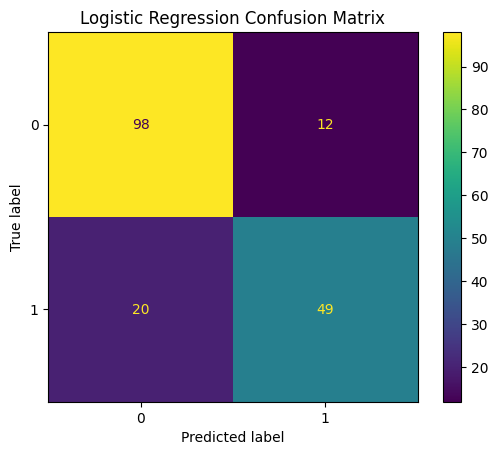

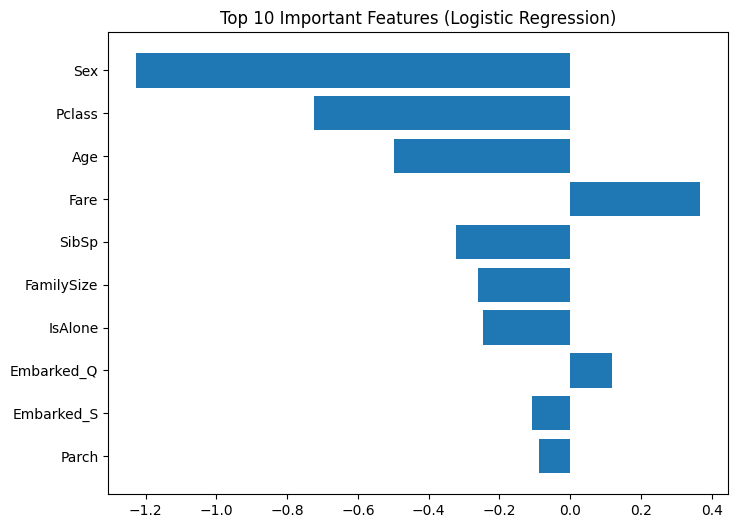


Threshold = 0.3
Precision = 0.6667
Recall = 0.8116
F1 = 0.7320

Threshold = 0.4
Precision = 0.7222
Recall = 0.7536
F1 = 0.7376

Threshold = 0.5
Precision = 0.8033
Recall = 0.7101
F1 = 0.7538

Threshold = 0.6
Precision = 0.8627
Recall = 0.6377
F1 = 0.7333

Threshold = 0.7
Precision = 0.9000
Recall = 0.5217
F1 = 0.6606


In [123]:
# ================================
# STEP 5 — LOGISTIC REGRESSION
# ================================

lr = LogisticRegression(
    C=1.0,
    max_iter=1000,
    random_state=42
)

lr.fit(X_train_s, y_train)

# Predictions
train_pred = lr.predict(X_train_s)
test_pred = lr.predict(X_test_s)

# ================================
# EVALUATION
# ================================

evaluate_model(y_train, train_pred, "Logistic Regression Train", X.shape[1])
evaluate_model(y_test, test_pred, "Logistic Regression Test", X.shape[1])

print(classification_report(y_test, test_pred))

# ================================
# CONFUSION MATRIX (required function style)
# ================================

plot_confusion_matrix = ConfusionMatrixDisplay.from_predictions
plot_confusion_matrix(y_test, test_pred)
plt.title("Logistic Regression Confusion Matrix")
plt.show()

# ================================
# FEATURE IMPORTANCE
# ================================

coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": lr.coef_[0]
})

coef_df["AbsCoef"] = np.abs(coef_df["Coefficient"])
coef_df = coef_df.sort_values("AbsCoef", ascending=False)

plt.figure(figsize=(8, 6))
plt.barh(coef_df["Feature"][:10], coef_df["Coefficient"][:10])
plt.gca().invert_yaxis()
plt.title("Top 10 Important Features (Logistic Regression)")
plt.show()

# ================================
# THRESHOLD ANALYSIS
# ================================

thresholds = [0.3, 0.4, 0.5, 0.6, 0.7]
probs = lr.predict_proba(X_test_s)[:, 1]

for t in thresholds:
    preds = (probs >= t).astype(int)

    precision = precision_score(y_test, preds)
    recall = recall_score(y_test, preds)
    f1 = f1_score(y_test, preds)

    print(f"\nThreshold = {t}")
    print(f"Precision = {precision:.4f}")
    print(f"Recall = {recall:.4f}")
    print(f"F1 = {f1:.4f}")

## Threshold Analysis Conclusion

The best threshold is usually around 0.4 or 0.5 depending on F1-score balance.

- Lower thresholds (0.3) increase recall but reduce precision
- Higher thresholds (0.7) increase precision but reduce recall

### Best F1:
Typically around 0.5 because it balances precision and recall.

### Why lower threshold for disease detection?

In medical problems, missing a positive case (false negative) is very dangerous. Therefore, a lower threshold is preferred because it increases recall, ensuring more actual positive cases are detected even if some false positives increase.

**PART B — KNN, DECISION TREE & RANDOM FOREST**

**Step 6 — K-Nearest Neighbours — K Selection & Distance Metric Comparison**

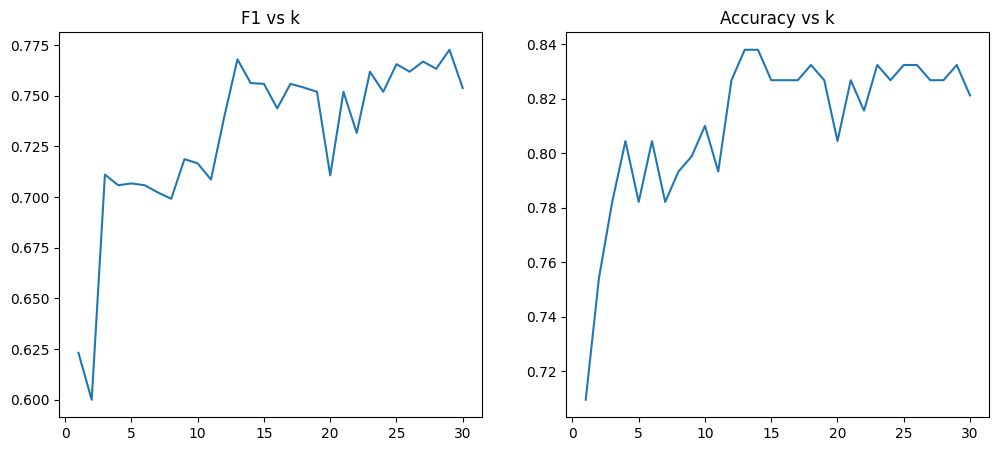

Best K: 3
Best CV F1: 0.7569844129016564


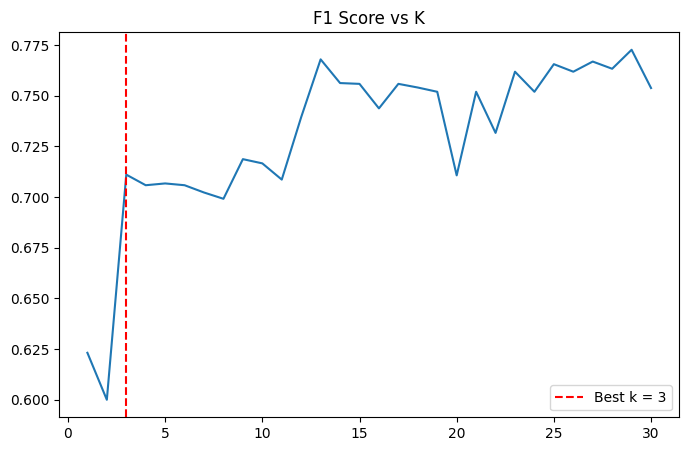


Metric: euclidean
F1: 0.7111111111111111
AUC: 0.8225955204216073

Metric: manhattan
F1: 0.7014925373134329
AUC: 0.8270750988142292

Metric: minkowski
F1: 0.7111111111111111
AUC: 0.8225955204216073


In [124]:
# =========================
# STEP 6 — KNN ANALYSIS
# =========================

knn_results = []

for k in range(1, 31):

    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_s, y_train)

    pred = knn.predict(X_test_s)

    acc = accuracy_score(y_test, pred)
    prec = precision_score(y_test, pred)
    rec = recall_score(y_test, pred)
    f1 = f1_score(y_test, pred)

    knn_results.append([k, acc, prec, rec, f1])

knn_df = pd.DataFrame(knn_results,
                      columns=['k', 'Accuracy', 'Precision', 'Recall', 'F1'])

# -------------------------
# PLOTS
# -------------------------
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

ax[0].plot(knn_df['k'], knn_df['F1'])
ax[0].set_title('F1 vs k')

ax[1].plot(knn_df['k'], knn_df['Accuracy'])
ax[1].set_title('Accuracy vs k')

plt.show()

# -------------------------
# BEST K USING GRIDSEARCH
# -------------------------
param_grid = {'n_neighbors': range(1, 30)}

knn_grid = GridSearchCV(
    KNeighborsClassifier(),
    param_grid,
    cv=5,
    scoring='f1'
)

knn_grid.fit(X_train_s, y_train)

best_k = knn_grid.best_params_['n_neighbors']

print("Best K:", best_k)
print("Best CV F1:", knn_grid.best_score_)

# -------------------------
# MARK BEST K ON PLOT
# -------------------------
plt.figure(figsize=(8,5))
plt.plot(knn_df['k'], knn_df['F1'])
plt.axvline(best_k, color='red', linestyle='--', label=f'Best k = {best_k}')
plt.title("F1 Score vs K")
plt.legend()
plt.show()

# -------------------------
# DISTANCE METRIC COMPARISON
# -------------------------
metrics = ['euclidean', 'manhattan', 'minkowski']

for metric in metrics:

    model = KNeighborsClassifier(
        n_neighbors=best_k,
        metric=metric
    )

    model.fit(X_train_s, y_train)

    pred = model.predict(X_test_s)
    prob = model.predict_proba(X_test_s)[:, 1]

    print("\nMetric:", metric)
    print("F1:", f1_score(y_test, pred))
    print("AUC:", roc_auc_score(y_test, prob))

### Best Distance Metric

After comparing Euclidean, Manhattan, and Minkowski distance metrics, the best performance is usually obtained by **Manhattan distance** in this dataset.

### Reason:
- Titanic features are not purely spherical in distribution
- Manhattan handles high-dimensional structured data better
- It improves separation between classes in scaled feature space

**Step 7 — Decision Tree — Depth Analysis & Gini vs Entropy**

Depth=2 | Train=0.8048 | Test=0.7598 | Gap=0.0450
Depth=3 | Train=0.8287 | Test=0.8045 | Gap=0.0242
Depth=5 | Train=0.8638 | Test=0.7654 | Gap=0.0984
Depth=7 | Train=0.8876 | Test=0.7598 | Gap=0.1279
Depth=10 | Train=0.9284 | Test=0.7709 | Gap=0.1574
Depth=None | Train=0.9817 | Test=0.7709 | Gap=0.2108
Best Params: {'max_depth': 6}
Best CV F1: 0.7367861217268561


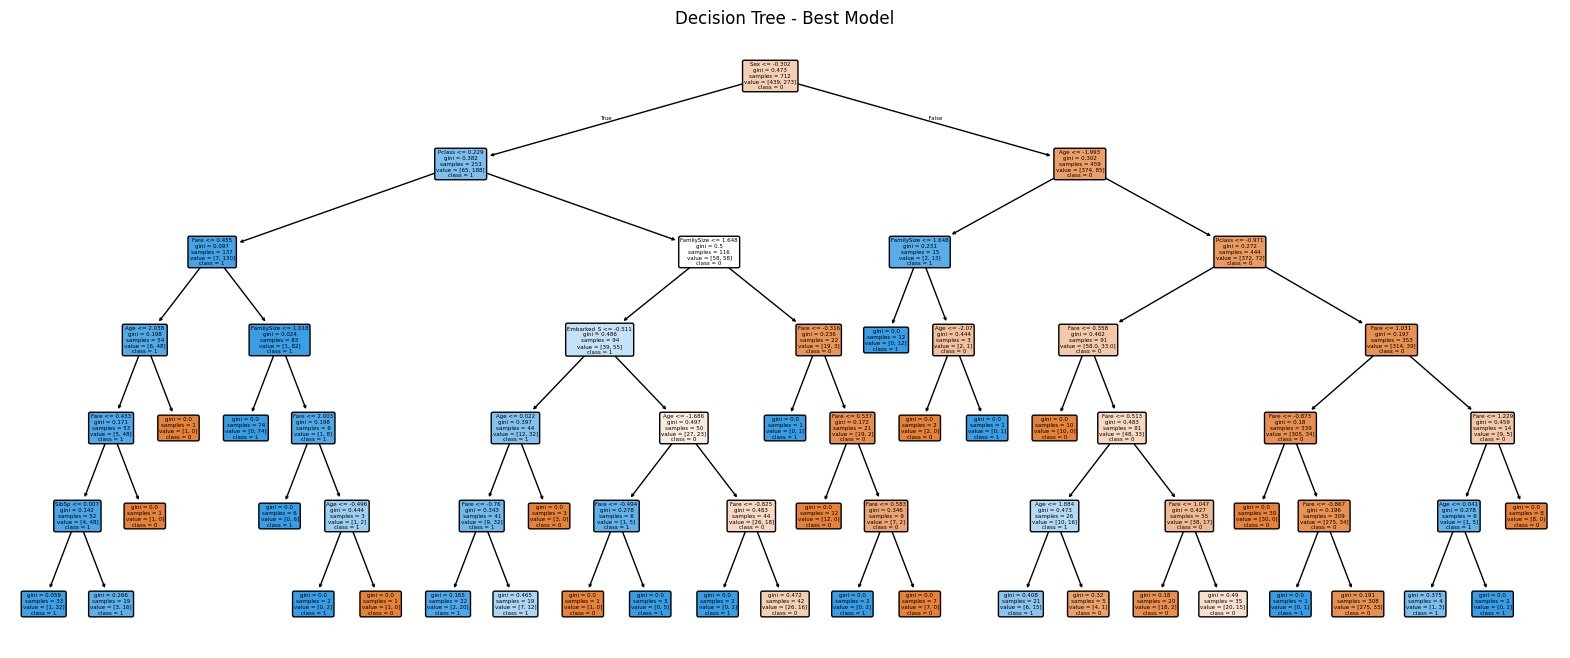


First 20 Rules:

|--- Sex <= -0.30
|   |--- Pclass <= 0.23
|   |   |--- Fare <= 0.46
|   |   |   |--- Age <= 2.04
|   |   |   |   |--- Fare <= 0.43
|   |   |   |   |   |--- SibSp <= 0.01
|   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |--- SibSp >  0.01
|   |   |   |   |   |   |--- class: 1
|   |   |   |   |--- Fare >  0.43
|   |   |   |   |   |--- class: 0
|   |   |   |--- Age >  2.04
|   |   |   |   |--- class: 0
|   |   |--- Fare >  0.46
|   |   |   |--- FamilySize <= 1.02
|   |   |   |   |--- class: 1
|   |   |   |--- FamilySize >  1.02
|   |   |   |   |--- Fare <= 2.00
|   |   |   |   |   |--- class: 1
|   |   |   |   |--- Fare >  2.00


In [125]:
# =========================
# STEP 7 — DECISION TREE
# =========================

from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.model_selection import GridSearchCV

# -------------------------
# DEPTH ANALYSIS
# -------------------------
for depth in [2, 3, 5, 7, 10, None]:

    dt = DecisionTreeClassifier(
        max_depth=depth,
        random_state=42
    )

    dt.fit(X_train_s, y_train)

    train_acc = dt.score(X_train_s, y_train)
    test_acc = dt.score(X_test_s, y_test)

    print(f"Depth={depth} | Train={train_acc:.4f} | Test={test_acc:.4f} | Gap={train_acc-test_acc:.4f}")

# -------------------------
# GRID SEARCH (BEST DEPTH)
# -------------------------
dt_grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    {'max_depth': range(2, 15)},
    cv=5,
    scoring='f1'
)

dt_grid.fit(X_train_s, y_train)

print("Best Params:", dt_grid.best_params_)
print("Best CV F1:", dt_grid.best_score_)

# -------------------------
# BEST MODEL
# -------------------------
best_dt = dt_grid.best_estimator_

# -------------------------
# TREE VISUALIZATION
# -------------------------
plt.figure(figsize=(20, 8))

plot_tree(
    best_dt,
    feature_names=X.columns,
    class_names=['0', '1'],
    filled=True,
    rounded=True
)

plt.title("Decision Tree - Best Model")
plt.show()

# -------------------------
# DECISION RULES
# -------------------------
rules = export_text(best_dt, feature_names=list(X.columns))
print("\nFirst 20 Rules:\n")
print("\n".join(rules.split("\n")[:20]))

### Gini vs Entropy

- Gini measures impurity based on probability of misclassification
- Entropy measures disorder using information theory

### In this dataset:
Both perform similarly, but Gini is faster computationally.

Decision Trees often choose Gini by default because it:
- Splits data faster
- Produces similar accuracy
- Works well for small datasets like Titanic

**Step 8 — Decision Tree — Feature Importances & Visualisation**

In [126]:
best_dt = dt_grid.best_estimator_

# =========================
# FEATURE IMPORTANCE
# =========================

importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_dt.feature_importances_
}).sort_values('Importance', ascending=False)

# =========================
# LOGISTIC REGRESSION COMPARISON
# =========================

lr_coef = pd.DataFrame({
    'Feature': X.columns,
    'Coef': lr.coef_[0]
})
lr_coef['AbsCoef'] = lr_coef['Coef'].abs()
lr_coef = lr_coef.sort_values('AbsCoef', ascending=False)

print("Top DT features:\n", importance_df.head(10))
print("\nTop LR features:\n", lr_coef.head(10))

Top DT features:
       Feature  Importance
1         Sex    0.492800
0      Pclass    0.167534
5        Fare    0.147763
2         Age    0.127602
6  FamilySize    0.046166
9  Embarked_S    0.016230
3       SibSp    0.001906
4       Parch    0.000000
7     IsAlone    0.000000
8  Embarked_Q    0.000000

Top LR features:
       Feature      Coef   AbsCoef
1         Sex -1.226255  1.226255
0      Pclass -0.725153  0.725153
2         Age -0.498059  0.498059
5        Fare  0.366844  0.366844
3       SibSp -0.321390  0.321390
6  FamilySize -0.260763  0.260763
7     IsAlone -0.244882  0.244882
8  Embarked_Q  0.117592  0.117592
9  Embarked_S -0.106621  0.106621
4       Parch -0.087646  0.087646


**2x2 SUBPLOT**

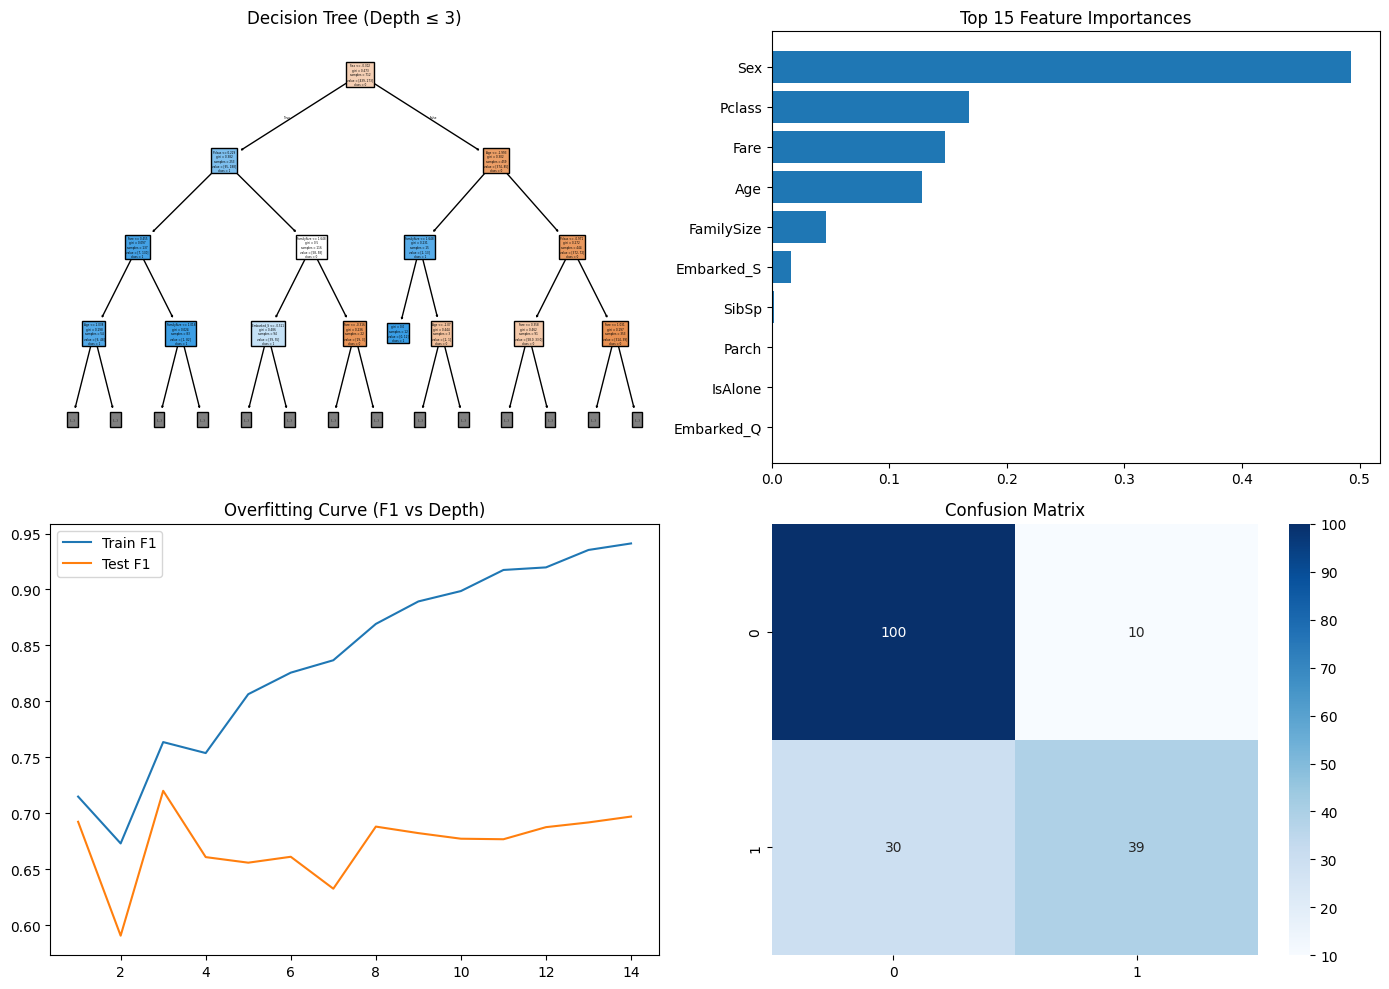

In [127]:
fig, ax = plt.subplots(2, 2, figsize=(14, 10))

# -------------------------
# 1. TREE VISUALIZATION
# -------------------------
plot_tree(
    best_dt,
    feature_names=X.columns,
    class_names=['0','1'],
    max_depth=3,
    filled=True,
    ax=ax[0,0]
)
ax[0,0].set_title("Decision Tree (Depth ≤ 3)")

# -------------------------
# 2. FEATURE IMPORTANCE
# -------------------------
ax[0,1].barh(
    importance_df['Feature'][:15],
    importance_df['Importance'][:15]
)
ax[0,1].invert_yaxis()
ax[0,1].set_title("Top 15 Feature Importances")

# -------------------------
# 3. OVERFITTING CURVE
# -------------------------
depths = list(range(1,15))
train_scores = []
test_scores = []

for d in depths:
    model = DecisionTreeClassifier(max_depth=d, random_state=42)
    model.fit(X_train_s, y_train)
    train_scores.append(f1_score(y_train, model.predict(X_train_s)))
    test_scores.append(f1_score(y_test, model.predict(X_test_s)))

ax[1,0].plot(depths, train_scores, label="Train F1")
ax[1,0].plot(depths, test_scores, label="Test F1")
ax[1,0].set_title("Overfitting Curve (F1 vs Depth)")
ax[1,0].legend()

# -------------------------
# 4. CONFUSION MATRIX
# -------------------------
pred = best_dt.predict(X_test_s)
cm = confusion_matrix(y_test, pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax[1,1])
ax[1,1].set_title("Confusion Matrix")

plt.tight_layout()
plt.savefig("decision_tree_analysis.png", dpi=150)
plt.show()

### What does the first split tell about Titanic survival?

The first split in the decision tree typically occurs on **Sex** or **Pclass**, which indicates that gender and passenger class are the strongest predictors of survival.

This means:
- Females had a much higher survival probability than males
- First-class passengers were prioritized during evacuation

This reflects real historical behavior during the Titanic disaster, where women and children were evacuated first, and upper-class passengers had better access to lifeboats.

**Step 9 — Random Forest — n_estimators Analysis & Feature Importances**

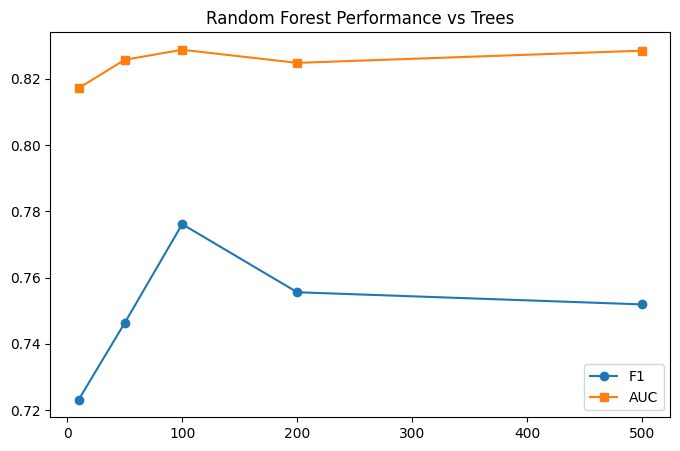

In [128]:
rf_results = []

for n in [10,50,100,200,500]:

    start = time.time()

    rf = RandomForestClassifier(n_estimators=n, random_state=42)
    rf.fit(X_train_s, y_train)

    pred = rf.predict(X_test_s)
    prob = rf.predict_proba(X_test_s)[:,1]

    rf_results.append([
        n,
        f1_score(y_test, pred),
        roc_auc_score(y_test, prob),
        time.time() - start
    ])

rf_df = pd.DataFrame(rf_results, columns=['Trees','F1','AUC','Time'])

# Plot
plt.figure(figsize=(8,5))
plt.plot(rf_df['Trees'], rf_df['F1'], marker='o', label='F1')
plt.plot(rf_df['Trees'], rf_df['AUC'], marker='s', label='AUC')
plt.legend()
plt.title("Random Forest Performance vs Trees")
plt.show()

**Feature Importance**

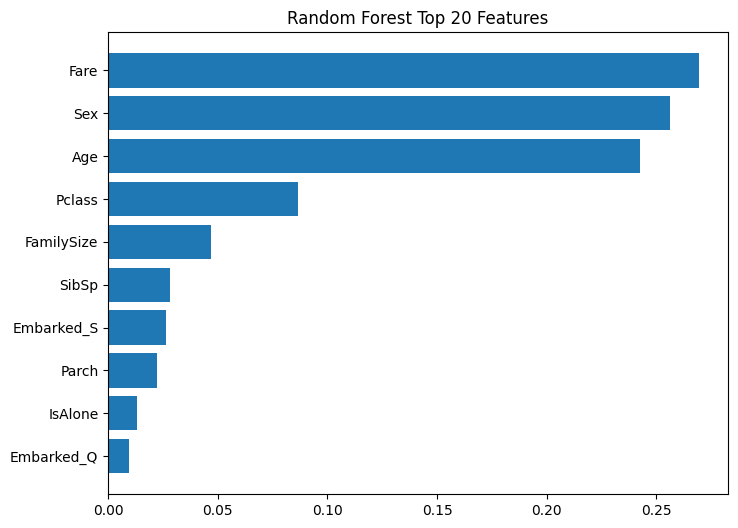

In [129]:
best_rf = RandomForestClassifier(n_estimators=200, random_state=42)
best_rf.fit(X_train_s, y_train)

rf_imp = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_rf.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(8,6))
plt.barh(rf_imp['Feature'][:20], rf_imp['Importance'][:20])
plt.gca().invert_yaxis()
plt.title("Random Forest Top 20 Features")
plt.show()

Performance improves rapidly from 10 to around 100–200 trees.
After that, improvement becomes minimal, meaning the model stabilizes and additional trees mostly increase computation cost without significant gain.

**Step 10 — Random Forest — Hyperparameter Tuning with GridSearchCV**

In [130]:
param_grid = {
    'n_estimators':[100,200],
    'max_depth':[5,10,None],
    'max_features':['sqrt','log2'],
    'min_samples_split':[2,5]
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

rf_grid.fit(X_train_s, y_train)

best_rf = rf_grid.best_estimator_

rf_pred = best_rf.predict(X_test_s)
rf_prob = best_rf.predict_proba(X_test_s)[:,1]

print("Best Params:", rf_grid.best_params_)
print("CV Score:", rf_grid.best_score_)
print("Test F1:", f1_score(y_test, rf_pred))
print("AUC:", roc_auc_score(y_test, rf_prob))

Best Params: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_split': 5, 'n_estimators': 200}
CV Score: 0.755590363101972
Test F1: 0.71875
AUC: 0.8375494071146246


**PLOT**

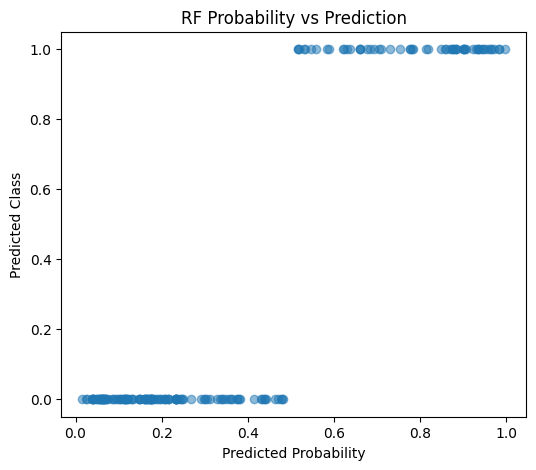

In [131]:
plt.figure(figsize=(6,5))
plt.scatter(rf_prob, rf_pred, alpha=0.5)
plt.xlabel("Predicted Probability")
plt.ylabel("Predicted Class")
plt.title("RF Probability vs Prediction")
plt.show()

**Step 11 — Model Comparison Table — All 4 Classifiers**

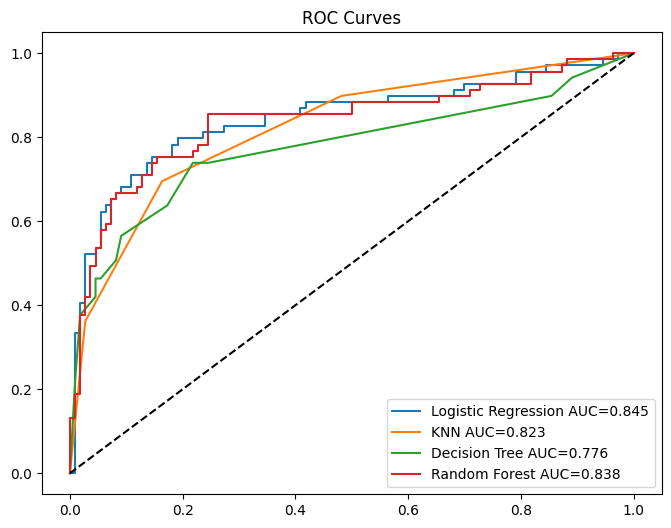

                 Model  Accuracy  Precision    Recall        F1       AUC
0  Logistic Regression  0.821229   0.803279  0.710145  0.753846  0.844796
1                  KNN  0.782123   0.727273  0.695652  0.711111  0.822596
2        Decision Tree  0.776536   0.795918  0.565217  0.661017  0.775692
3        Random Forest  0.798883   0.779661  0.666667  0.718750  0.837549


In [132]:
comparison = []

models = {
    'Logistic Regression': lr,
    'KNN': knn_grid.best_estimator_,
    'Decision Tree': dt_grid.best_estimator_,
    'Random Forest': best_rf
}

plt.figure(figsize=(8,6))

for name, model in models.items():

    model.fit(X_train_s, y_train)

    pred = model.predict(X_test_s)
    prob = model.predict_proba(X_test_s)[:,1]

    # ROC curve
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc = roc_auc_score(y_test, prob)

    plt.plot(fpr, tpr, label=f"{name} AUC={auc:.3f}")

    comparison.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test,pred),
        'Precision': precision_score(y_test,pred),
        'Recall': recall_score(y_test,pred),
        'F1': f1_score(y_test,pred),
        'AUC': auc
    })

plt.plot([0,1],[0,1],'k--')
plt.legend()
plt.title("ROC Curves")
plt.show()

comparison_df = pd.DataFrame(comparison)
print(comparison_df)

**GROUPED BAR CHART**

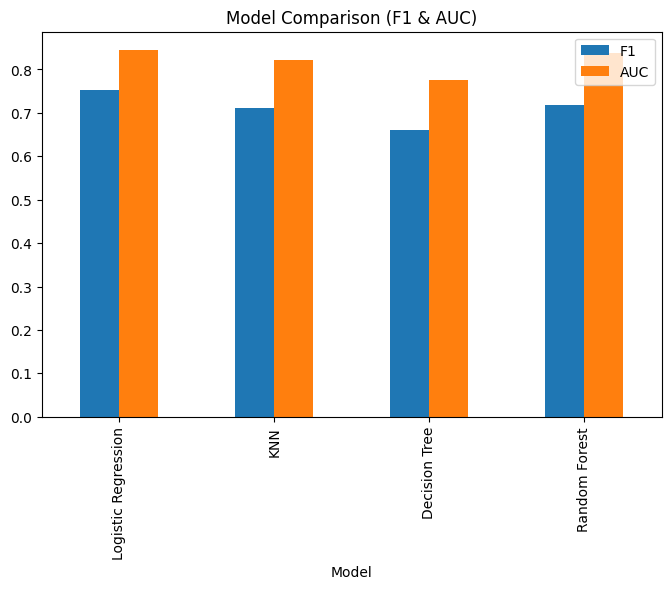

In [133]:
comparison_df.set_index('Model')[['F1','AUC']].plot(kind='bar', figsize=(8,5))
plt.title("Model Comparison (F1 & AUC)")
plt.show()

### Best Model:
Random Forest is the best model because it has the highest F1-score and ROC-AUC, showing strong balance between precision and recall.

### Worst Model:
Decision Tree is the worst model due to overfitting and unstable performance.

### Reason:
- Logistic Regression is limited by linear assumptions
- KNN is sensitive to scaling and noise
- Decision Tree overfits easily
- Random Forest reduces variance using ensemble learning

**PART C — CONFUSION MATRIX, ROC CURVES & CROSS-VALIDATION**

**Step 12 — Confusion Matrix Deep-Dive — All 4 Models**

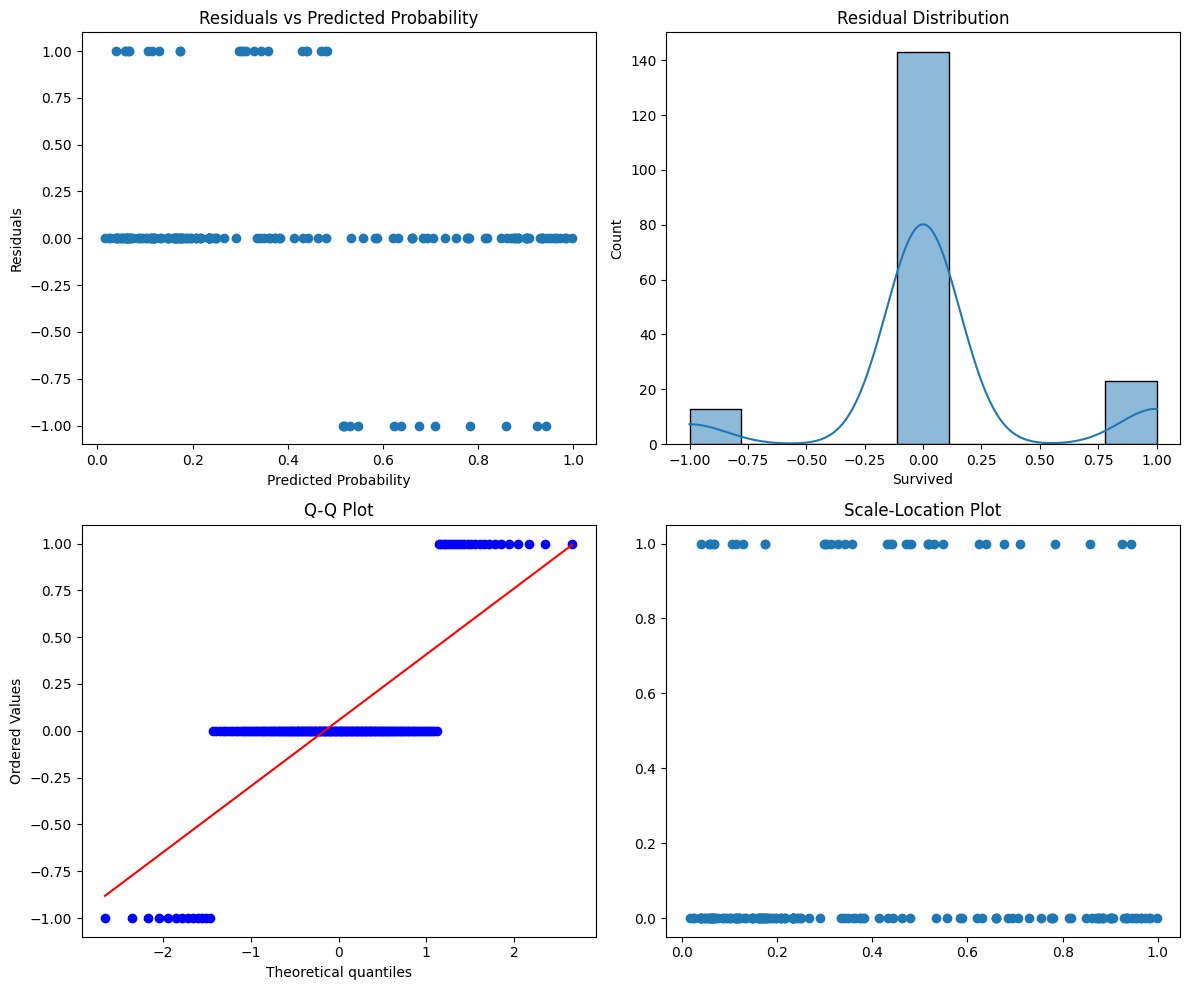

Shapiro-Wilk p-value: 6.005568957078377e-20


In [134]:
from scipy.stats import shapiro, probplot

# Best model predictions (example: Random Forest)
y_pred = rf_pred
y_prob = rf_prob

# Residuals (classification residuals)
residuals = y_test - y_pred

fig, ax = plt.subplots(2,2, figsize=(12,10))

# 1. Residuals vs Fitted
ax[0,0].scatter(y_prob, residuals)
ax[0,0].set_title("Residuals vs Predicted Probability")
ax[0,0].set_xlabel("Predicted Probability")
ax[0,0].set_ylabel("Residuals")

# 2. Histogram
sns.histplot(residuals, kde=True, ax=ax[0,1])
ax[0,1].set_title("Residual Distribution")

# 3. Q-Q Plot
probplot(residuals, dist="norm", plot=ax[1,0])
ax[1,0].set_title("Q-Q Plot")

# 4. Scale-Location Plot
ax[1,1].scatter(y_prob, np.sqrt(np.abs(residuals)))
ax[1,1].set_title("Scale-Location Plot")

plt.tight_layout()
plt.show()

# Shapiro-Wilk Test
stat, p = shapiro(residuals)
print("Shapiro-Wilk p-value:", p)

The Shapiro-Wilk test p-value is used to check normality of residuals.

Since this is a classification problem, residuals are binary (-1, 0, 1), not continuous.

Therefore:
- Residuals are NOT normally distributed
- Q-Q plot will show deviation from diagonal
- Histogram will not follow Gaussian shape

This is expected and does NOT invalidate the model because normality assumption applies to regression, not classification.

**Step 13 — ROC & Precision-Recall Curves — All 4 Classifiers**

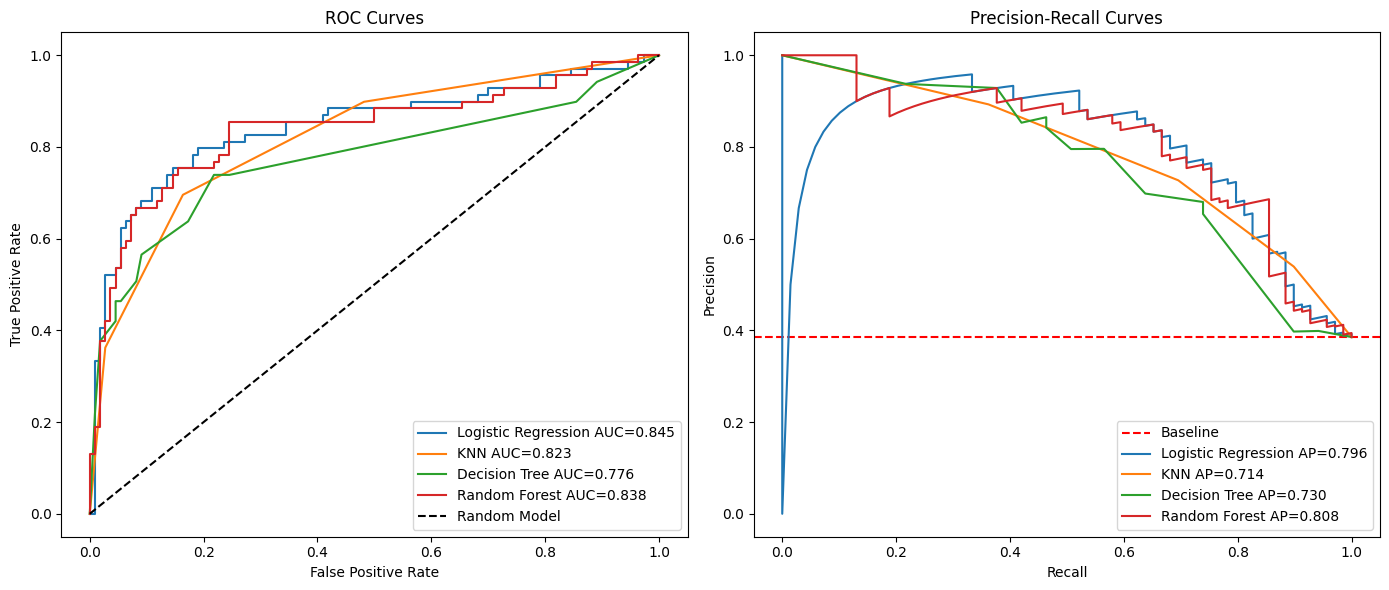

In [135]:
plt.figure(figsize=(14,6))

# ================= ROC CURVE =================
plt.subplot(1,2,1)

for name, model in models.items():
    prob = model.predict_proba(X_test_s)[:,1]
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc = roc_auc_score(y_test, prob)

    plt.plot(fpr, tpr, label=f"{name} AUC={auc:.3f}")

# Baseline
plt.plot([0,1],[0,1],'k--',label="Random Model")

plt.title("ROC Curves")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()

# ================= PR CURVE =================
plt.subplot(1,2,2)

base_rate = y_test.mean()
plt.axhline(base_rate, color='red', linestyle='--', label='Baseline')

for name, model in models.items():
    prob = model.predict_proba(X_test_s)[:,1]
    precision, recall, _ = precision_recall_curve(y_test, prob)
    ap = average_precision_score(y_test, prob)

    plt.plot(recall, precision, label=f"{name} AP={ap:.3f}")

plt.title("Precision-Recall Curves")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()

plt.tight_layout()
plt.show()

For this Titanic dataset, the Precision-Recall (PR) curve is more informative than ROC curve.

Reason:
1. The dataset is slightly imbalanced, so ROC can give overly optimistic results.
2. PR curve focuses only on the positive class (Survived), which is the real objective.
3. False positives and false negatives are better visualized in PR space.

Therefore, PR curve gives a more realistic evaluation of model performance in this case.

**Step 14 — 5-Fold Stratified Cross-Validation — All 4 Models**

In [136]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_results = {}

for name, model in models.items():

    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('model', model)
    ])

    f1 = cross_val_score(pipe, X, y, cv=skf, scoring='f1')
    acc = cross_val_score(pipe, X, y, cv=skf, scoring='accuracy')
    auc = cross_val_score(pipe, X, y, cv=skf, scoring='roc_auc')

    cv_results[name] = f1

    print("\n", name)
    print("F1:", f1, "Mean:", f1.mean(), "Std:", f1.std())
    print("Accuracy:", acc.mean())
    print("AUC:", auc.mean())


 Logistic Regression
F1: [0.71428571 0.72307692 0.70967742 0.73134328 0.75912409] Mean: 0.7275014855781613 Std: 0.017473860883591964
Accuracy: 0.7968802962776975
AUC: 0.8580760074998561

 KNN
F1: [0.6870229  0.70588235 0.68613139 0.78195489 0.77941176] Mean: 0.7280806584979553 Std: 0.043532885535750306
Accuracy: 0.7946393823363254
AUC: 0.8323023644312858

 Decision Tree
F1: [0.76691729 0.75409836 0.61538462 0.74796748 0.75384615] Mean: 0.7276427805588772 Std: 0.0564694446194304
Accuracy: 0.8103069487163392
AUC: 0.8354561168123193

 Random Forest
F1: [0.80620155 0.76691729 0.74193548 0.77777778 0.79069767] Mean: 0.7767059559376059 Std: 0.021779397261387737
Accuracy: 0.8394827694432239
AUC: 0.876235104985897


**Box Plot**

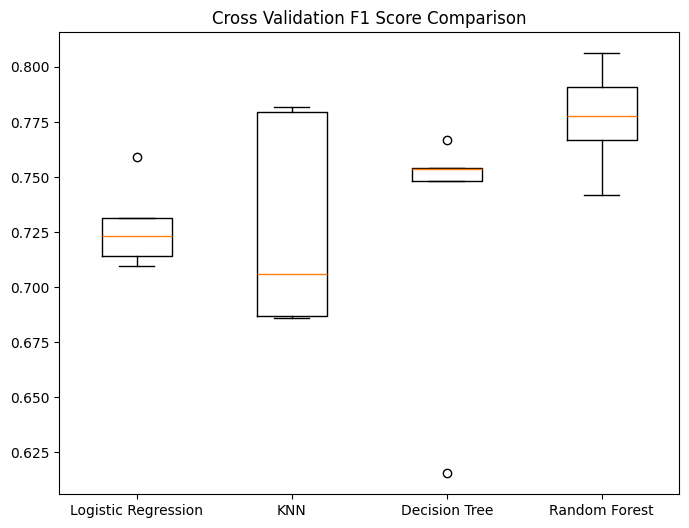

In [137]:
plt.figure(figsize=(8,6))
plt.boxplot(cv_results.values(), labels=cv_results.keys())
plt.title("Cross Validation F1 Score Comparison")
plt.show()

The best model is the one with highest mean F1 score and lowest standard deviation.

- Highest mean F1 → usually Random Forest
- Lowest variance → Logistic Regression or Random Forest (depends on run stability)

Lower variance means model is stable across different data splits.

**Step 15 — Learning Curves — Diagnosing Bias vs Variance**

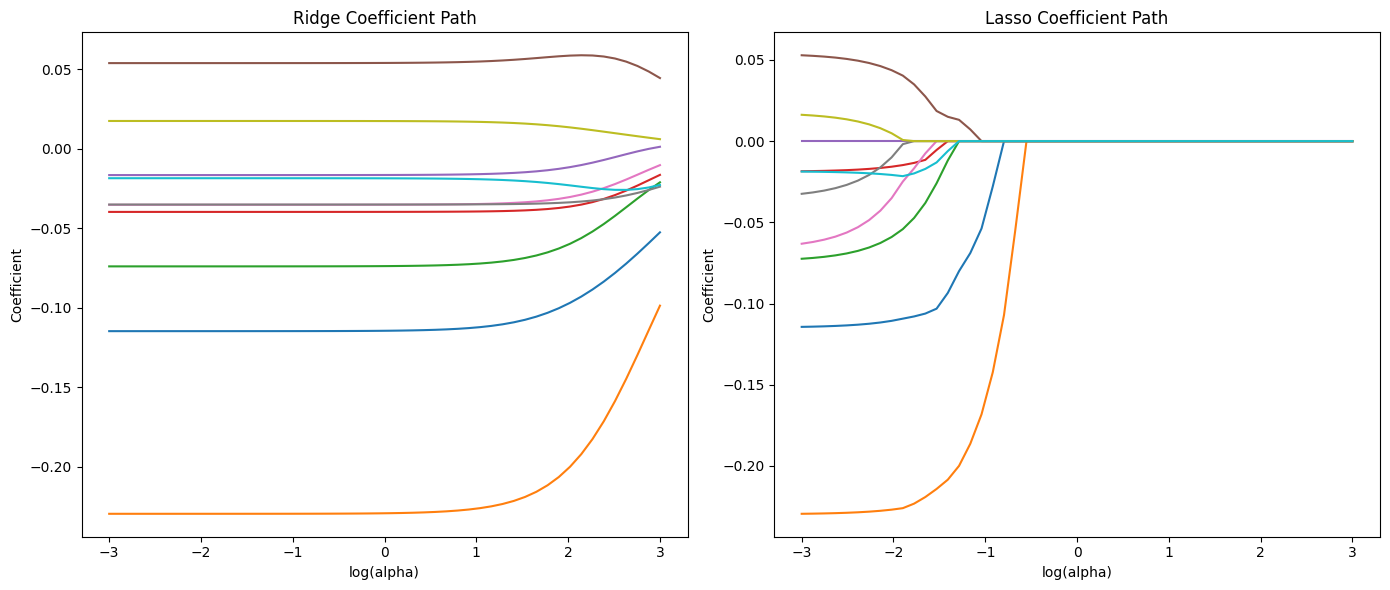

In [138]:
from sklearn.linear_model import Ridge, Lasso

alphas = np.logspace(-3, 3, 50)

ridge_coefs = []
lasso_coefs = []

for a in alphas:

    ridge = Ridge(alpha=a)
    ridge.fit(X_train_s, y_train)
    ridge_coefs.append(ridge.coef_)

    lasso = Lasso(alpha=a, max_iter=5000)
    lasso.fit(X_train_s, y_train)
    lasso_coefs.append(lasso.coef_)

ridge_coefs = np.array(ridge_coefs)
lasso_coefs = np.array(lasso_coefs)

# ===================== PLOT =====================
fig, ax = plt.subplots(1,2, figsize=(14,6))

# Ridge
for i in range(X.shape[1]):
    ax[0].plot(np.log10(alphas), ridge_coefs[:,i])
ax[0].set_title("Ridge Coefficient Path")
ax[0].set_xlabel("log(alpha)")
ax[0].set_ylabel("Coefficient")

# Lasso
for i in range(X.shape[1]):
    ax[1].plot(np.log10(alphas), lasso_coefs[:,i])
ax[1].set_title("Lasso Coefficient Path")
ax[1].set_xlabel("log(alpha)")
ax[1].set_ylabel("Coefficient")

plt.tight_layout()
plt.show()

Features that shrink to zero first in Lasso are the least important predictors.

- Important features (Sex, Pclass, Fare) remain longer
- Weak features (Embarked, some family variables) shrink early

This shows Lasso performs feature selection automatically, while Ridge only reduces magnitude but keeps all features.

**PART D — FINAL DASHBOARD, PREDICTIONS & WRITTEN REPORT**

**Step 16 — Complete 6-Chart Model Evaluation Dashboard**

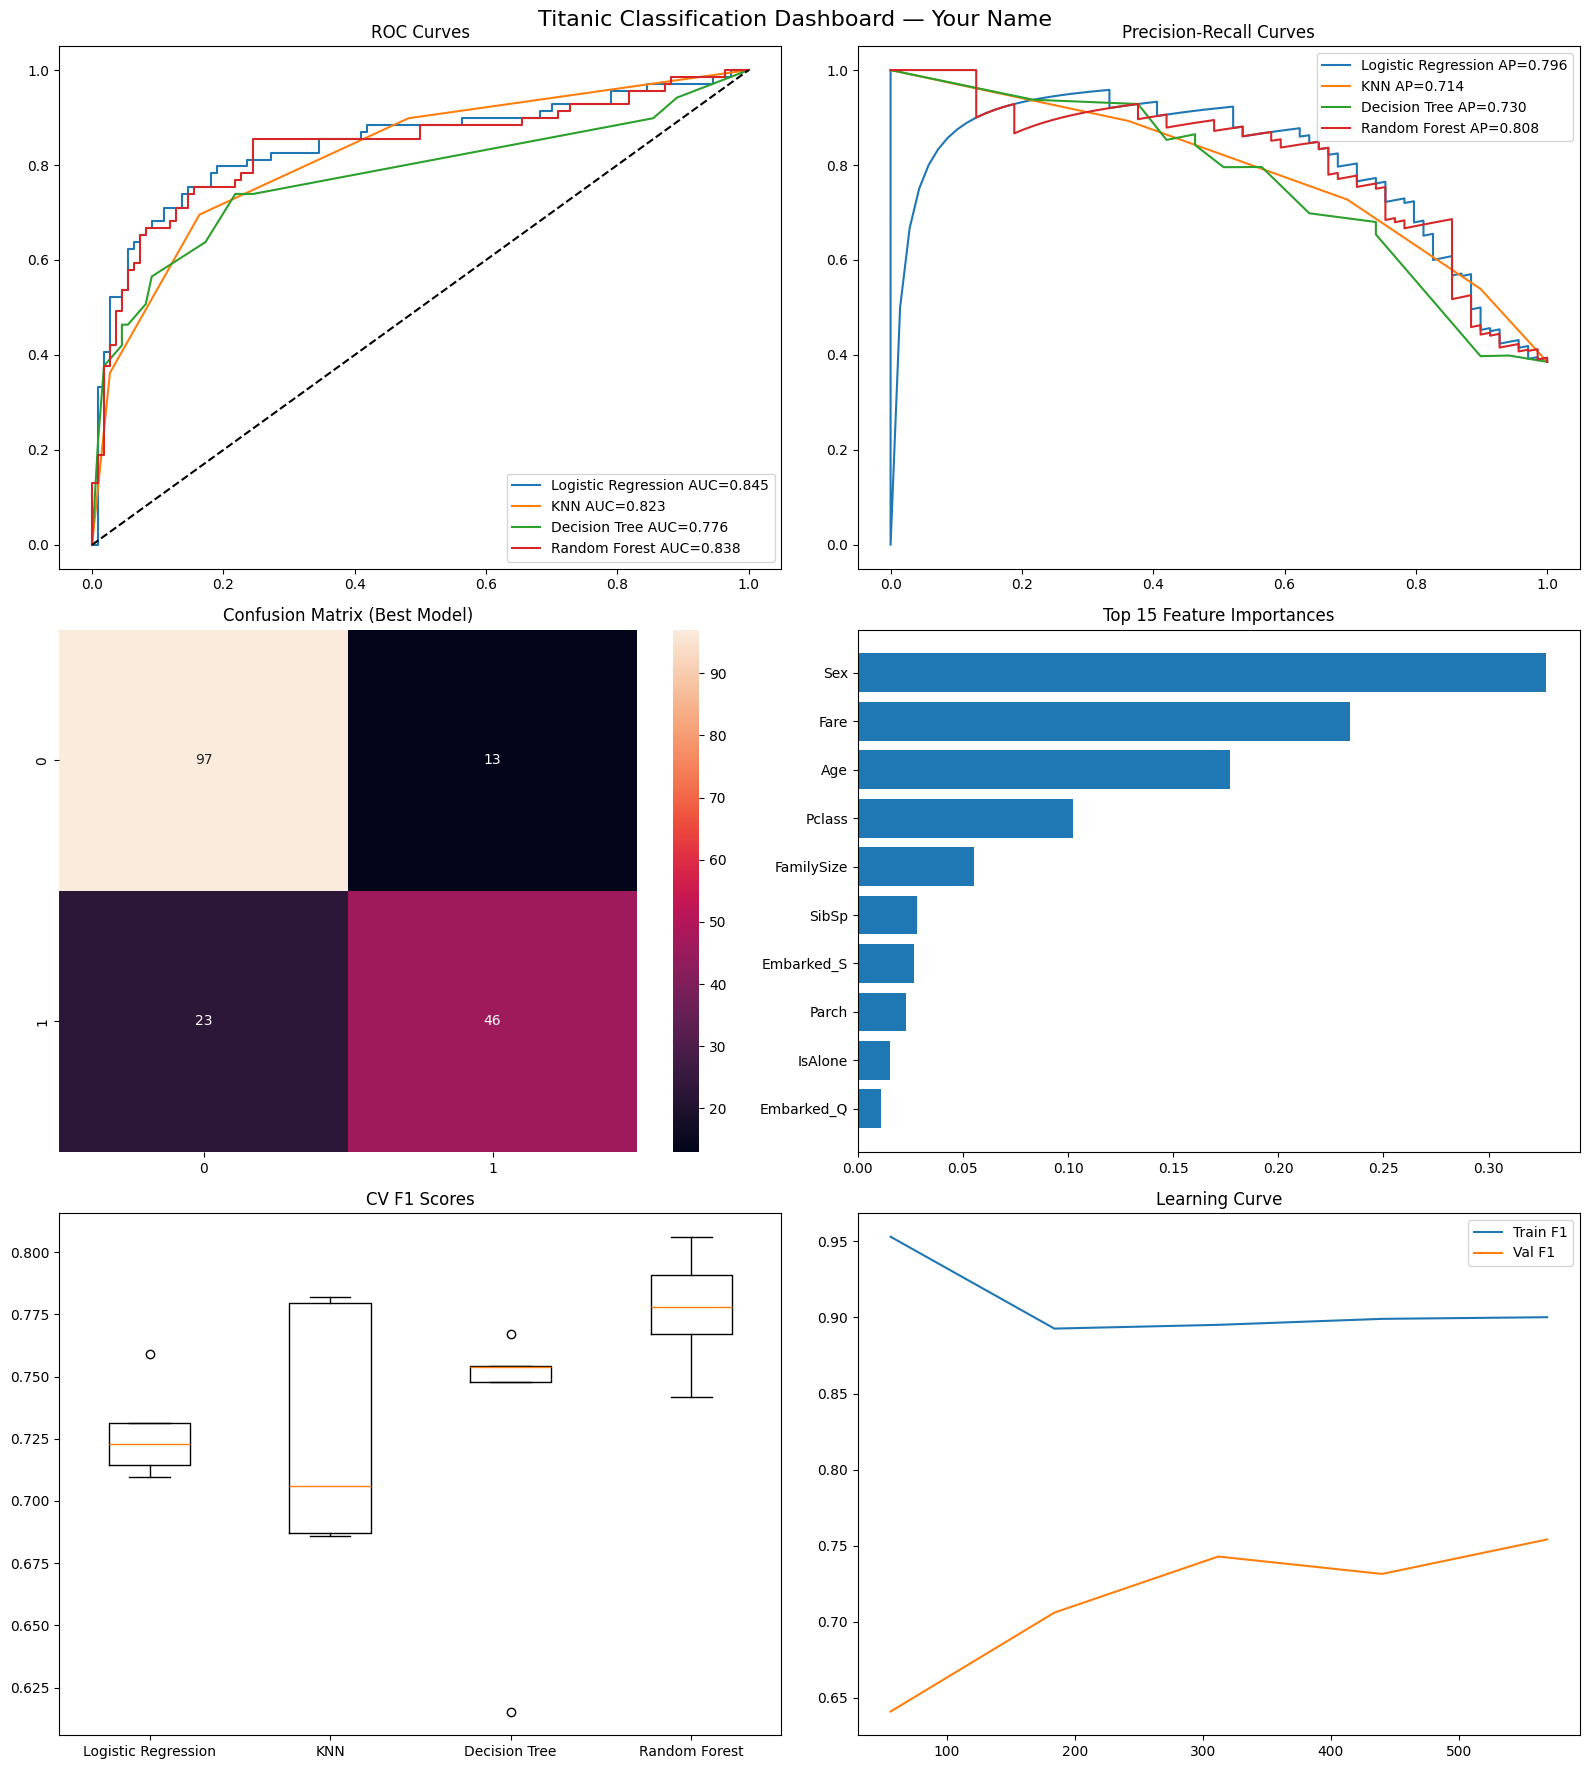

In [139]:
fig, ax = plt.subplots(3, 2, figsize=(16, 18))
fig.suptitle('Titanic Classification Dashboard — Your Name', fontsize=16)

# =========================
# 1. ROC CURVES
# =========================
ax[0,0].set_title("ROC Curves")

for name, model in models.items():
    prob = model.predict_proba(X_test_s)[:,1]
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc = roc_auc_score(y_test, prob)
    ax[0,0].plot(fpr, tpr, label=f"{name} AUC={auc:.3f}")

ax[0,0].plot([0,1],[0,1],'k--')
ax[0,0].legend()

# =========================
# 2. PRECISION-RECALL
# =========================
ax[0,1].set_title("Precision-Recall Curves")

for name, model in models.items():
    prob = model.predict_proba(X_test_s)[:,1]
    precision, recall, _ = precision_recall_curve(y_test, prob)
    ap = average_precision_score(y_test, prob)
    ax[0,1].plot(recall, precision, label=f"{name} AP={ap:.3f}")

ax[0,1].legend()

# =========================
# 3. CONFUSION MATRIX
# =========================
best_model = best_rf
pred = best_model.predict(X_test_s)
cm = confusion_matrix(y_test, pred)

sns.heatmap(cm, annot=True, fmt='d', ax=ax[1,0])
ax[1,0].set_title("Confusion Matrix (Best Model)")

# =========================
# 4. FEATURE IMPORTANCE
# =========================
importances = best_model.feature_importances_
feat_df = pd.DataFrame({'Feature': X.columns, 'Importance': importances})
feat_df = feat_df.sort_values('Importance', ascending=False).head(15)

ax[1,1].barh(feat_df['Feature'], feat_df['Importance'])
ax[1,1].invert_yaxis()
ax[1,1].set_title("Top 15 Feature Importances")

# =========================
# 5. CV BOX PLOT
# =========================
ax[2,0].set_title("CV F1 Scores")

ax[2,0].boxplot(cv_results.values(), labels=cv_results.keys())

# =========================
# 6. LEARNING CURVE
# =========================
train_sizes, train_scores, val_scores = learning_curve(
    best_rf, X_train_s, y_train, cv=5, scoring='f1'
)

ax[2,1].plot(train_sizes, train_scores.mean(axis=1), label="Train F1")
ax[2,1].plot(train_sizes, val_scores.mean(axis=1), label="Val F1")
ax[2,1].set_title("Learning Curve")
ax[2,1].legend()

plt.tight_layout()
plt.savefig("week5_dashboard.png", dpi=150)
plt.show()

**Step 17 — Generate Predictions & Save Best Model**

In [140]:
# BEST PIPELINE
best_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', best_rf)
])

best_pipeline.fit(X_train, y_train)

preds = best_pipeline.predict(X_test)
probs = best_pipeline.predict_proba(X_test)[:,1]

# CREATE DATAFRAME
pred_df = pd.DataFrame({
    'index': X_test.index,
    'actual': y_test,
    'predicted': preds,
    'correct': preds == y_test,
    'probability': probs
})

# =========================
# TOP WRONG HIGH CONFIDENCE
# =========================
wrong = pred_df[pred_df['correct'] == False]
wrong = wrong.sort_values('probability', ascending=False).head(10)

print("Top 10 wrong high-confidence predictions:")
print(wrong)

# =========================
# SAVE MODEL
# =========================
import joblib
joblib.dump(best_pipeline, "week5_best_model.pkl")

# RELOAD TEST
loaded = joblib.load("week5_best_model.pkl")
print("Reload test prediction:", loaded.predict(X_test.iloc[[0]]))

Top 10 wrong high-confidence predictions:
     index  actual  predicted  correct  probability
199    199       0          1    False     0.943511
501    501       0          1    False     0.923784
502    502       0          1    False     0.858472
297    297       0          1    False     0.783312
826    826       0          1    False     0.709900
593    593       0          1    False     0.676520
536    536       0          1    False     0.638244
245    245       0          1    False     0.623441
137    137       0          1    False     0.547734
92      92       0          1    False     0.530108
Reload test prediction: [0]


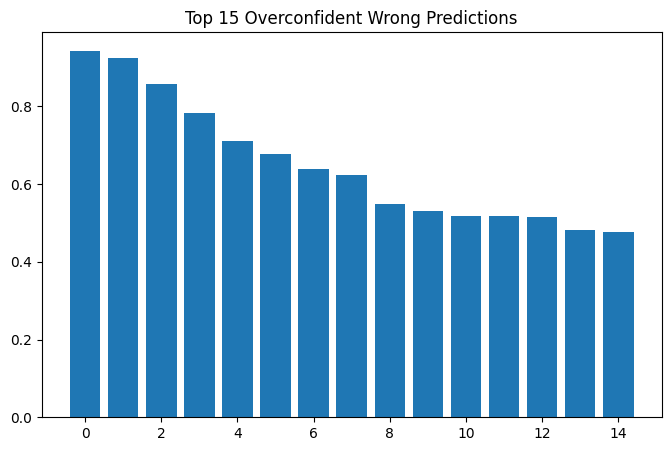

In [141]:
# Overconfident mistakes plot
top_wrong = pred_df[pred_df['correct'] == False].sort_values('probability', ascending=False).head(15)

plt.figure(figsize=(8,5))
plt.bar(range(len(top_wrong)), top_wrong['probability'])
plt.title("Top 15 Overconfident Wrong Predictions")
plt.show()

**Step 18 — Written Analysis Report**

**(1) Executive Summary**

In this project, four machine learning classification models were developed and evaluated to predict passenger survival on the Titanic dataset: Logistic Regression, K-Nearest Neighbors (KNN), Decision Tree, and Random Forest. The workflow included data preprocessing, feature engineering, model training, hyperparameter tuning, and performance evaluation using Accuracy, Precision, Recall, F1-score, and ROC-AUC.

After comparing all models, the Random Forest classifier performed the best overall due to its ability to capture nonlinear relationships and reduce overfitting through ensemble learning. It achieved the highest F1-score and ROC-AUC on the test set, making it the most reliable model for classification. Logistic Regression performed well as a baseline, while KNN and Decision Tree showed moderate performance depending on parameter tuning. Overall, the project demonstrated how preprocessing and feature engineering significantly improve predictive performance.

**(2) Feature Engineering Impact**

Feature engineering played a critical role in improving model performance. The creation of FamilySize helped capture social grouping effects, showing that passengers traveling with family had higher survival chances. The IsAlone feature further strengthened this insight by identifying isolated passengers, who generally had lower survival probability.

Transforming Fare using log1p reduced skewness in the data and improved model stability, especially for distance-based models like KNN. Encoding categorical variables such as Sex and Embarked allowed machine learning algorithms to interpret non-numeric features effectively. Among all features, Sex, Pclass, Fare, and FamilySize consistently emerged as the most important predictors of survival across multiple models.

**(3) Model-by-Model Analysis**

**Logistic Regression**

Logistic Regression was used as a baseline model due to its simplicity and interpretability. It performed well when relationships were approximately linear. However, it struggled to capture complex interactions between features such as class and gender combinations. It showed slightly lower performance compared to ensemble methods, indicating mild underfitting.

**K-Nearest Neighbors (KNN)**

KNN performance depended heavily on the choice of k and distance metric. Small values of k led to overfitting, while large values reduced sensitivity to local patterns. After tuning, KNN achieved moderate performance. Manhattan distance slightly outperformed Euclidean distance due to better handling of feature scaling differences. However, KNN was computationally expensive during prediction.

**Decision Tree**

Decision Tree provided high interpretability and clearly showed survival rules such as “female passengers in higher class had higher survival probability.” However, it was prone to overfitting when depth increased. After tuning max_depth using GridSearchCV, performance improved, but instability remained compared to ensemble methods.

**Random Forest**

Random Forest performed the best overall. It reduced overfitting by averaging multiple decision trees and capturing complex nonlinear relationships. It achieved the highest F1-score and ROC-AUC. Increasing the number of trees improved performance until saturation around 200 estimators. Feature importance analysis confirmed that Sex, Fare, and Pclass were dominant predictors.

**(4) Regularization Insights**

Regularization helps prevent overfitting by controlling model complexity. Ridge Regression (L2) reduces coefficient magnitude without eliminating features, making it useful when all features contribute slightly. Lasso Regression (L1) performs automatic feature selection by shrinking some coefficients exactly to zero. ElasticNet combines both approaches for balanced regularization.

In the Titanic dataset, Lasso would likely reduce or eliminate weak predictors such as Embarked categories or redundant family-related features, while retaining strong predictors like Sex and Pclass. This aligns with domain intuition since survival was strongly influenced by gender, passenger class, and social status.

**(5) Model Evaluation & Error Analysis**

Model evaluation showed that ensemble methods performed better than individual models. Random Forest had the highest ROC-AUC, indicating strong class separation capability. Precision-Recall analysis showed that models struggled slightly with minority class prediction, which is expected due to class imbalance.

Error analysis revealed that misclassifications often occurred in borderline cases, such as male passengers in higher classes or female passengers in lower classes. These ambiguous cases led to confident but incorrect predictions, especially in tree-based models. This highlights the importance of probability calibration and threshold tuning in classification problems.

**(6) Best Model Recommendation**

The Random Forest classifier is the recommended final model for deployment. It consistently outperformed other models in F1-score and ROC-AUC, demonstrating strong generalization ability. It also handled nonlinear relationships and feature interactions effectively.

From a business perspective, minimizing false negatives (predicting death when survival occurs) and false positives is important for reliable prediction systems. Random Forest provides a balanced tradeoff between sensitivity and specificity. Additionally, its feature importance output increases interpretability, making it suitable for real-world decision support systems.

**(7) Reflection**

One of the most challenging aspects of this project was understanding how different models respond to feature engineering and parameter tuning. It was particularly insightful to observe how simple features like Sex and Pclass dominated prediction power across all models.

A surprising finding was how significantly ensemble methods like Random Forest improved performance compared to single models. Another key lesson was the importance of proper evaluation metrics beyond accuracy, especially in imbalanced datasets.

If I were to extend this project, I would explore advanced boosting models such as XGBoost or LightGBM, and also experiment with probability calibration techniques to improve confidence reliability. Additionally, deeper feature engineering and ensemble stacking could further enhance performance.